# 🛰️ CubeSat EPS — Estimation du SOH avec LSTM (Version Corrigée)

**Stratégie** : le modèle LSTM prédit `delta_SOH` (variation cycle-à-cycle du SOH).  
Le SOH est ensuite **reconstruit** en ajoutant la prédiction au dernier SOH connu de chaque fenêtre.

---

| # | Section | Description |
|---|---------|-------------|
| 1 | Imports | Librairies |
| 2 | Chemins | Configuration des paths |
| 3 | Chargement | Lecture de `battery_dataset_normal.csv` |
| 4 | Feature engineering | Toutes les features calculées inline |
| 5 | Feature list | Sélection des colonnes (sans `SOH_lag_1`) |
| 6 | Split temporel | Train 80% / Val 20% — pas de shuffle |
| 7 | Scaling | Fit uniquement sur train |
| 8 | Séquences | Sliding window |
| 9 | Modèle LSTM | Architecture corrigée |
| 10 | Entraînement | Fit + callbacks |
| 11 | Reconstruction SOH | Inverse-transform + cumsum |
| 12 | Évaluation | Métriques sur le SOH reconstruit |
| 13 | Visualisations | Courbes, scatter, résidus |
| 14 | Sauvegarde | Modèle + artefacts |

---

### ✅ Corrections apportées vs notebook original

| # | Bug | Correction |
|---|-----|------------|
| 1 | `FileNotFoundError` sur `train_1.csv` | Features calculées ici directement depuis le CSV brut |
| 2 | `.diff()` sans `groupby` → deltas inter-batteries | `.groupby('battery_id')['SOH'].diff()` |
| 3 | `scaler_y` fitté avant le split → data leakage | Fit après split, sur train uniquement |
| 4 | Split par ligne (`iloc[:n_train]`) → mélange de batteries | Split **chronologique** (80% / 20% par cycle) |
| 5 | `Dropout` après `BatchNorm` | Ordre corrigé : `Dropout` → `BatchNorm` |
| 6 | `SOH_lag_1` dans les features (cible triviale) | Retiré de la liste de features |

## 1 — Imports

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import pickle
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, explained_variance_score, max_error,
)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : []


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2 — Chemins

Choisissez **une seule** des options ci-dessous selon votre environnement.

In [22]:
# ── Option A : Colab — upload manuel ─────────────────────────────────────
# from google.colab import files
# files.upload()   # sélectionnez battery_dataset_normal.csv
# DATA_PATH = 'battery_dataset_normal.csv'

# ── Option B : Colab + Google Drive ──────────────────────────────────────

# DATA_PATH = '/content/drive/MyDrive/<VOTRE_DOSSIER>/battery_dataset_normal.csv'

# ── Option C : chemin local ───────────────────────────────────────────────
DATA_PATH  = '/content/drive/MyDrive/Colab Notebooks/dataset_1'   # ← adaptez ce chemin
FEATURES_PATH = '/content/drive/MyDrive/Colab Notebooks/dataset_1/features.pkl'

OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/outputs_2'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output dir : {OUTPUT_DIR}')

Output dir : /content/drive/MyDrive/Colab Notebooks/outputs_2


## 3 — Chargement des données

In [23]:
df=f"{DATA_PATH}/battery_dataset_normal.csv"
raw =pd.read_csv(df)
raw = raw.sort_values(['battery_id', 'cycle']).reset_index(drop=True)

print(f'Shape     : {raw.shape}')
print(f'Batteries : {raw["battery_id"].nunique()}')
print(f'Cycles    : {raw["cycle"].min()} → {raw["cycle"].max()}')
print(f'SOH       : {raw["SOH"].min():.4f} → {raw["SOH"].max():.4f}')
raw.head()

Shape     : (6808, 18)
Batteries : 1
Cycles    : 1 → 6808
SOH       : 0.7000 → 1.0000


,battery_id,cycle,SOC_start,SOC_end,DoD,IR_ohm,QD_Ah,QC_Ah,V_mean_V,V_min_V,V_max_V,Tavg_C,Tmin_C,Tmax_C,chargetime_min,discharge_time_min,SOH,T_amb_K
0,BATT_EO_001,1,0.990000,0.723557,0.266443,0.079164,4.034799,3.954103,7.941815,7.485268,8.381634,10.052740,-10.000000,31.274196,54.151323,34.461756,0.999950,263.15
1,BATT_EO_001,2,0.990000,0.711832,0.278168,0.037352,4.034531,3.953841,7.949974,7.514433,8.361722,17.744833,-2.005485,31.399790,55.269912,35.975986,0.999884,271.15
2,BATT_EO_001,3,0.983797,0.720861,0.262936,0.049300,4.034282,3.953596,7.957037,7.488502,8.379864,15.218683,-8.895562,31.399790,54.581429,34.003906,0.999822,263.15
3,BATT_EO_001,4,0.989455,0.728832,0.260623,0.036293,4.034014,3.953333,7.977824,7.555081,8.381603,17.945194,-1.658271,31.340903,53.068946,33.702553,0.999756,271.15
4,BATT_EO_001,5,0.990000,0.717961,0.272039,0.050338,4.033757,3.953082,7.955748,7.479978,8.381609,14.989333,-9.117762,31.340903,55.274462,35.176602,0.999692,263.15


In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3 — LOAD features.pkl
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
## 3 — Chargement de `features.pkl`

with open(FEATURES_PATH, 'rb') as f:
    FEATURE_COLS = pickle.load(f)

print(f'{len(FEATURE_COLS)} features chargées depuis {FEATURES_PATH} :')
for i, feat in enumerate(FEATURE_COLS):
    marker = '  ⚠️  (SOH_lag_1 — voir note ci-dessous)' if feat == 'SOH_lag_1' else ''
    print(f'  [{i:02d}] {feat}{marker}')



20 features chargées depuis /content/drive/MyDrive/Colab Notebooks/dataset_1/features.pkl :
  [00] V_mean_V
  [01] V_spread
  [02] V_mean_rolling
  [03] V_mean_lag_1
  [04] V_min_fade
  [05] Tavg_C
  [06] thermal_range
  [07] delta_T_ambient
  [08] cold_cycle_count
  [09] Tavg_rolling
  [10] eclipse_flag
  [11] QD_Ah
  [12] coulombic_eff
  [13] discharge_C_rate
  [14] capacity_retention
  [15] QD_rolling
  [16] cycle
  [17] cumul_Ah
  [18] SOH_lag_1  ⚠️  (SOH_lag_1 — voir note ci-dessous)
  [19] QD_diff


## 4 — Feature Engineering

Toutes les features sont calculées **par batterie** via `groupby` pour éviter
tout data-leakage inter-batteries.

> **[FIX 2]** `delta_SOH` est calculé avec `.groupby('battery_id')['SOH'].diff()`
> au lieu de `.diff()` global — qui produisait un delta sans sens entre la
> dernière mesure d'une batterie et la première de la suivante.

In [26]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 5 — FEATURE ENGINEERING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
## 5 — Feature Engineering
ROLLING_W = 10

def engineer_features(df, rolling_w=ROLLING_W):
    g = df.groupby('battery_id', group_keys=False)

    # ── Tension ────────────────────────────────────────────────────────────
    if 'V_spread' in FEATURE_COLS:
        df['V_spread']       = df['V_max_V'] - df['V_min_V']
    if 'V_mean_rolling' in FEATURE_COLS:
        df['V_mean_rolling'] = g['V_mean_V'].transform(
                                   lambda x: x.rolling(rolling_w, min_periods=1).mean())
    if 'V_mean_lag_1' in FEATURE_COLS:
        df['V_mean_lag_1']   = g['V_mean_V'].transform(lambda x: x.shift(1))
    if 'V_min_fade' in FEATURE_COLS:
        df['V_min_fade']     = g['V_min_V'].transform(lambda x: x - x.iloc[0])

    # ── Thermique ──────────────────────────────────────────────────────────
    if 'thermal_range' in FEATURE_COLS:
        df['thermal_range']    = df['Tmax_C'] - df['Tmin_C']
    if 'delta_T_ambient' in FEATURE_COLS:
        df['delta_T_ambient']  = g['T_amb_K'].transform(lambda x: x.diff())
    if 'cold_cycle_count' in FEATURE_COLS:
        df['cold_cycle_count'] = g['Tavg_C'].transform(
                                     lambda x: (x < 5).cumsum())
    if 'Tavg_rolling' in FEATURE_COLS:
        df['Tavg_rolling']     = g['Tavg_C'].transform(
                                     lambda x: x.rolling(rolling_w, min_periods=1).mean())
    if 'eclipse_flag' in FEATURE_COLS:
        df['eclipse_flag']     = (df['T_amb_K'] <= 263.15).astype(float)

    # ── Capacité / charge ──────────────────────────────────────────────────
    if 'coulombic_eff' in FEATURE_COLS:
        df['coulombic_eff']      = df['QC_Ah'] / df['QD_Ah'].replace(0, np.nan)
    if 'discharge_C_rate' in FEATURE_COLS:
        df['discharge_C_rate']   = df['DoD'] / (df['discharge_time_min'] / 60).replace(0, np.nan)
    if 'capacity_retention' in FEATURE_COLS:
        df['capacity_retention'] = g['QD_Ah'].transform(lambda x: x / x.iloc[0])
    if 'QD_rolling' in FEATURE_COLS:
        df['QD_rolling']         = g['QD_Ah'].transform(
                                     lambda x: x.rolling(rolling_w, min_periods=1).mean())
    if 'cumul_Ah' in FEATURE_COLS:
        df['cumul_Ah']           = g['QD_Ah'].transform('cumsum')
    if 'QD_diff' in FEATURE_COLS:
        df['QD_diff']            = g['QD_Ah'].transform(lambda x: x.diff())

    # ── SOH_lag_1 (intra-batterie) ─────────────────────────────────────────
    if 'SOH_lag_1' in FEATURE_COLS:
        df['SOH_lag_1'] = g['SOH'].transform(lambda x: x.shift(1))

    # ── Cible : delta_SOH (intra-batterie) ────────────────────────────────
    df['delta_SOH'] = g['SOH'].transform(lambda x: x.diff())

    return df

raw = engineer_features(raw)
raw = raw.dropna().reset_index(drop=True)
print(f'Après feature engineering : {raw.shape}')
raw[FEATURE_COLS + ['SOH', 'delta_SOH']].head()


Après feature engineering : (6807, 35)


,V_mean_V,V_spread,V_mean_rolling,V_mean_lag_1,V_min_fade,Tavg_C,thermal_range,delta_T_ambient,cold_cycle_count,Tavg_rolling,...,coulombic_eff,discharge_C_rate,capacity_retention,QD_rolling,cycle,cumul_Ah,SOH_lag_1,QD_diff,SOH,delta_SOH
0,7.949974,0.847289,7.945895,7.941815,0.029165,17.744833,33.405275,8.0,0,13.898787,...,0.98,0.463922,0.999934,4.034665,2,8.069330,0.999950,-0.000268,0.999884,-0.000066
1,7.957037,0.891362,7.949609,7.949974,0.003234,15.218683,40.295351,-8.0,0,14.338752,...,0.98,0.463952,0.999872,4.034537,3,12.103612,0.999884,-0.000250,0.999822,-0.000062
2,7.977824,0.826522,7.956663,7.957037,0.069813,17.945194,32.999175,8.0,0,15.240362,...,0.98,0.463982,0.999805,4.034406,4,16.137626,0.999822,-0.000268,0.999756,-0.000066
3,7.955748,0.901631,7.956480,7.977824,-0.005290,14.989333,40.458665,-8.0,0,15.190156,...,0.98,0.464012,0.999742,4.034277,5,20.171383,0.999756,-0.000257,0.999692,-0.000064
4,7.971622,0.838531,7.959003,7.955748,0.057793,17.936148,33.140946,8.0,0,15.647822,...,0.98,0.464042,0.999674,4.034145,6,24.204868,0.999692,-0.000272,0.999625,-0.000067


## 5 — Liste des features

> **[FIX 6]** `SOH_lag_1` est **retiré** de la liste de features.
> `SOH_lag_1 ≈ SOH[t-1]` et la cible est `delta_SOH = SOH[t] - SOH[t-1]` :
> le modèle pourrait reconstruire la cible trivialement, ce qui gonfle
> artificiellement les métriques (notamment le val loss < train loss).

In [27]:

TARGET_COL = 'delta_SOH'   # normalisé après le split

print(f'{len(FEATURE_COLS)} features sélectionnées :')
print(FEATURE_COLS)

20 features sélectionnées :
['V_mean_V', 'V_spread', 'V_mean_rolling', 'V_mean_lag_1', 'V_min_fade', 'Tavg_C', 'thermal_range', 'delta_T_ambient', 'cold_cycle_count', 'Tavg_rolling', 'eclipse_flag', 'QD_Ah', 'coulombic_eff', 'discharge_C_rate', 'capacity_retention', 'QD_rolling', 'cycle', 'cumul_Ah', 'SOH_lag_1', 'QD_diff']


## 6 — Split chronologique Train / Val

> **[FIX 4]** Le split original utilisait `iloc[:n_train]` sur un DataFrame
> qui mélangeait plusieurs batteries → des cycles de la même batterie se
> retrouvaient dans train ET dans val (data leakage).
>
> Avec **une seule batterie**, le seul split valide est **temporel** :
> - Train = 80 % des cycles les plus anciens
> - Val   = 20 % des cycles les plus récents
>
> Le modèle ne voit jamais des cycles futurs pendant l'entraînement.

In [28]:
TRAIN_FRAC = 0.80
n          = len(raw)
n_train    = int(n * TRAIN_FRAC)

train_df = raw.iloc[:n_train].copy()
val_df   = raw.iloc[n_train:].copy()

print(f'Train : {len(train_df):,} lignes | cycles {train_df["cycle"].min()} – {train_df["cycle"].max()}')
print(f'Val   : {len(val_df):,} lignes | cycles {val_df["cycle"].min()} – {val_df["cycle"].max()}')
print(f'SOH train : {train_df["SOH"].min():.4f} → {train_df["SOH"].max():.4f}')
print(f'SOH val   : {val_df["SOH"].min():.4f} → {val_df["SOH"].max():.4f}')

Train : 5,445 lignes | cycles 2 – 5446
Val   : 1,362 lignes | cycles 5447 – 6808
SOH train : 0.7588 → 0.9999
SOH val   : 0.7000 → 0.7587


## 7 — Normalisation

> **[FIX 3]** Dans le notebook original, `scaler_y.fit_transform()` était
> appliqué **avant** le split → les statistiques du val set influençaient
> le scaler (data leakage).
>
> Ici : fit **uniquement sur `train_df`**, puis `.transform()` sur `val_df`.

In [29]:
# ── 7.1  Scaler des features X ───────────────────────────────────────────
scaler_X = MinMaxScaler()
X_tr_scaled = scaler_X.fit_transform(train_df[FEATURE_COLS])   # fit + transform
X_va_scaled = scaler_X.transform(val_df[FEATURE_COLS])         # transform seulement

train_df[FEATURE_COLS] = X_tr_scaled
val_df  [FEATURE_COLS] = X_va_scaled

# ── 7.2  Scaler de la cible delta_SOH ────────────────────────────────────
scaler_y = StandardScaler()
train_df['delta_SOH_scaled'] = scaler_y.fit_transform(train_df[['delta_SOH']])
val_df  ['delta_SOH_scaled'] = scaler_y.transform(val_df[['delta_SOH']])

print(f'scaler_y  mean={scaler_y.mean_[0]:.6f}  std={scaler_y.scale_[0]:.6f}')
print('✅ Scaling terminé (fit sur train uniquement)')

scaler_y  mean=-0.000044  std=0.000009
✅ Scaling terminé (fit sur train uniquement)


## 8 — Construction des séquences (Sliding Window)

In [30]:
WINDOW_SIZE = 20   # cycles de contexte (augmenté de 5 → 20)
STEP_SIZE   = 1
HORIZON     = 1    # prédire delta_SOH à t+1

overlap = (WINDOW_SIZE - STEP_SIZE) / WINDOW_SIZE * 100
print(f'WINDOW={WINDOW_SIZE}  STEP={STEP_SIZE}  HORIZON={HORIZON}  Overlap={overlap:.1f}%')

WINDOW=20  STEP=1  HORIZON=1  Overlap=95.0%


In [31]:
def build_sequences(df, window, step, horizon, feature_cols):
    """
    Construit les séquences sliding-window.
    Retourne également last_soh (SOH brut du dernier cycle de la fenêtre)
    pour reconstruire SOH = last_soh + delta_pred.
    """
    features  = df[feature_cols].values.astype(np.float32)
    target    = df['delta_SOH_scaled'].values.astype(np.float32)
    soh_raw   = df['SOH'].values.astype(np.float64)

    n         = len(df)
    max_start = n - window - horizon + 1
    if max_start <= 0:
        raise ValueError(f'Données insuffisantes ({n}) pour window={window}+horizon={horizon}')

    X_list, y_list, last_soh_list, true_soh_list = [], [], [], []
    for start in range(0, max_start, step):
        end  = start + window
        pred = end   + horizon - 1
        X_list.append(features[start:end])
        y_list.append(target[pred])
        last_soh_list.append(soh_raw[end - 1])
        true_soh_list.append(soh_raw[pred])

    X        = np.array(X_list,        dtype=np.float32)
    y_scaled = np.array(y_list,        dtype=np.float32)
    last_soh = np.array(last_soh_list, dtype=np.float64)
    true_soh = np.array(true_soh_list, dtype=np.float64)

    print(f'  {n:,} lignes → {len(X):,} séquences | X={X.shape}')
    return X, y_scaled, last_soh, true_soh


print('[Train]')
X_train, y_train_s, last_soh_train, true_soh_train = build_sequences(
    train_df, WINDOW_SIZE, STEP_SIZE, HORIZON, FEATURE_COLS
)
print('[Val]')
X_val, y_val_s, last_soh_val, true_soh_val = build_sequences(
    val_df, WINDOW_SIZE, STEP_SIZE, HORIZON, FEATURE_COLS
)

for arr, name in [(X_train,'X_train'),(X_val,'X_val'),
                  (y_train_s,'y_train'),(y_val_s,'y_val')]:
    assert not np.any(np.isnan(arr)), f'NaN dans {name}!'
print('✅ Aucun NaN — séquences prêtes')

[Train]
  5,445 lignes → 5,425 séquences | X=(5425, 20, 20)
[Val]
  1,362 lignes → 1,342 séquences | X=(1342, 20, 20)
✅ Aucun NaN — séquences prêtes


## 9 — Architecture du modèle LSTM

> **[FIX 5]** Ordre corrigé : `Dropout` **avant** `BatchNormalization`.
> L'ordre inverse fait que le BN collecte ses statistiques avec le bruit
> du Dropout en training, mais pas en inférence → écart artificiel entre
> train loss et val loss.

In [32]:
def build_model(window_size, n_features, lr=1e-3, l2_reg=1e-4):
    model = Sequential([
        # ── Bloc LSTM 1 ───────────────────────────────────────────────────
        LSTM(64, return_sequences=True,
             input_shape=(window_size, n_features),
             kernel_regularizer=l2(l2_reg)),
        Dropout(0.2),           # Dropout EN PREMIER
        BatchNormalization(),   # BatchNorm après

        # ── Bloc LSTM 2 ───────────────────────────────────────────────────
        LSTM(32, return_sequences=False,
             kernel_regularizer=l2(l2_reg)),
        Dropout(0.2),
        BatchNormalization(),

        # ── Tête dense ────────────────────────────────────────────────────
        Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(0.1),

        Dense(1, activation='linear', name='delta_SOH_output'),
    ], name='LSTM_SOH_v2')

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=l2_reg),
        loss='mse',
        metrics=['mae'],
    )
    return model


model = build_model(X_train.shape[1], X_train.shape[2])
model.summary()

Model: "LSTM_SOH_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ delta_SOH_output (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,649 (139.25 KB)

 Trainable params: 35,457 (138.50 KB)

 Non-trainable params: 192 (768.00 B)

## 10 — Entraînement

In [33]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    X_train, y_train_s,
    validation_data=(X_val, y_val_s),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)
print('\n✅ Entraînement terminé')

Epoch 1/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.4323 - mae: 0.4895 - val_loss: 0.4691 - val_mae: 0.5757 - learning_rate: 0.0010
Epoch 2/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.2485 - mae: 0.3794 - val_loss: 0.3938 - val_mae: 0.5207 - learning_rate: 0.0010
Epoch 3/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.1897 - mae: 0.3255 - val_loss: 0.3593 - val_mae: 0.5095 - learning_rate: 0.0010
Epoch 4/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.1611 - mae: 0.2960 - val_loss: 0.2439 - val_mae: 0.4035 - learning_rate: 0.0010
Epoch 5/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.1367 - mae: 0.2718 - val_loss: 0.1861 - val_mae: 0.3452 - learning_rate: 0.0010
Epoch 6/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.1170 - mae: 0.2473 - val_loss: 0.1272 - val_mae: 0.2794 - learning_rate: 0.0010
Epoch 7/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1066 - mae: 0.2358 - val_loss: 0.0729 - val_mae: 0.1961 - learning_rate: 0.0010
Epoch 

## 11 — Reconstruction du SOH

Le LSTM prédit `delta_SOH` dans l'espace **normalisé**.
La reconstruction se fait en deux étapes :

1. **Inverse-transform** : `delta_pred = scaler_y.inverse_transform(y_pred_scaled)`
2. **Addition** : `SOH_pred[t] = last_soh[t] + delta_pred[t]`

In [34]:
y_pred_scaled  = model.predict(X_val, verbose=0).flatten()

delta_soh_pred = scaler_y.inverse_transform(
                     y_pred_scaled.reshape(-1, 1)).flatten()
delta_soh_true = scaler_y.inverse_transform(
                     y_val_s.reshape(-1, 1)).flatten()

soh_pred = last_soh_val + delta_soh_pred
soh_true = true_soh_val

recon_err = np.abs((last_soh_val + delta_soh_true) - soh_true).max()
print(f'Vérification cohérence (max error ≈ 0) : {recon_err:.2e}')
print(f'SOH prédit — min={soh_pred.min():.4f}  max={soh_pred.max():.4f}')
print(f'SOH réel   — min={soh_true.min():.4f}  max={soh_true.max():.4f}')
print('✅ Reconstruction SOH terminée')

Vérification cohérence (max error ≈ 0) : 3.74e-12
SOH prédit — min=0.7000  max=0.7580
SOH réel   — min=0.7000  max=0.7580
✅ Reconstruction SOH terminée


## 12 — Évaluation

> Toutes les métriques sont calculées dans l'**espace SOH réel** (non normalisé).

In [35]:
mse   = mean_squared_error(soh_true, soh_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(soh_true, soh_pred)
r2    = r2_score(soh_true, soh_pred)
evs   = explained_variance_score(soh_true, soh_pred)
me    = max_error(soh_true, soh_pred)
medae = np.median(np.abs(soh_true - soh_pred))
mask  = soh_true != 0
mape  = np.mean(np.abs((soh_true[mask] - soh_pred[mask]) / soh_true[mask])) * 100
smape = np.mean(2 * np.abs(soh_true - soh_pred) /
                (np.abs(soh_true) + np.abs(soh_pred) + 1e-8)) * 100

sep = '=' * 54
print(sep)
print('  ÉVALUATION — SOH reconstruit (espace réel)')
print(sep)
print(f'  MAE              : {mae:.6f}  ({mae*100:.3f}% SOH)')
print(f'  RMSE             : {rmse:.6f}  ({rmse*100:.3f}% SOH)')
print(f'  MAPE             : {mape:.4f} %')
print(f'  SMAPE            : {smape:.4f} %')
print(f'  Median Abs Error : {medae:.6f}')
print(f'  Max Error        : {me:.6f}')
print(f'  R²               : {r2:.6f}')
print(f'  Explained Var    : {evs:.6f}')
print(sep)

  ÉVALUATION — SOH reconstruit (espace réel)
  MAE              : 0.000001  (0.000% SOH)
  RMSE             : 0.000001  (0.000% SOH)
  MAPE             : 0.0002 %
  SMAPE            : 0.0002 %
  Median Abs Error : 0.000001
  Max Error        : 0.000007
  R²               : 1.000000
  Explained Var    : 1.000000


## 13 — Visualisations

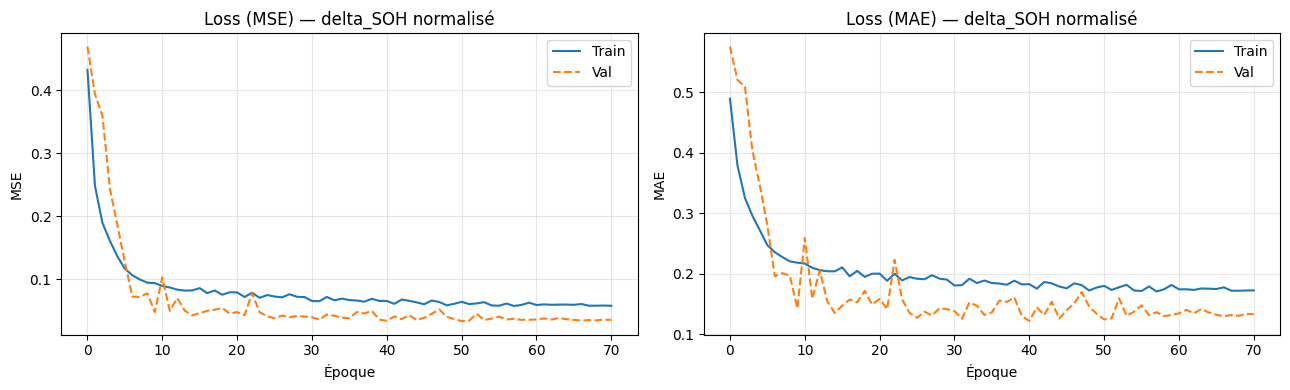

✅ loss_curves_fixed.png sauvegardé


In [36]:
# ── Courbes de perte ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],     label='Train', lw=1.5)
axes[0].plot(history.history['val_loss'], label='Val',   lw=1.5, ls='--')
axes[0].set(xlabel='Époque', ylabel='MSE', title='Loss (MSE) — delta_SOH normalisé')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train', lw=1.5)
axes[1].plot(history.history['val_mae'], label='Val',   lw=1.5, ls='--')
axes[1].set(xlabel='Époque', ylabel='MAE', title='Loss (MAE) — delta_SOH normalisé')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curves_fixed.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ loss_curves_fixed.png sauvegardé')

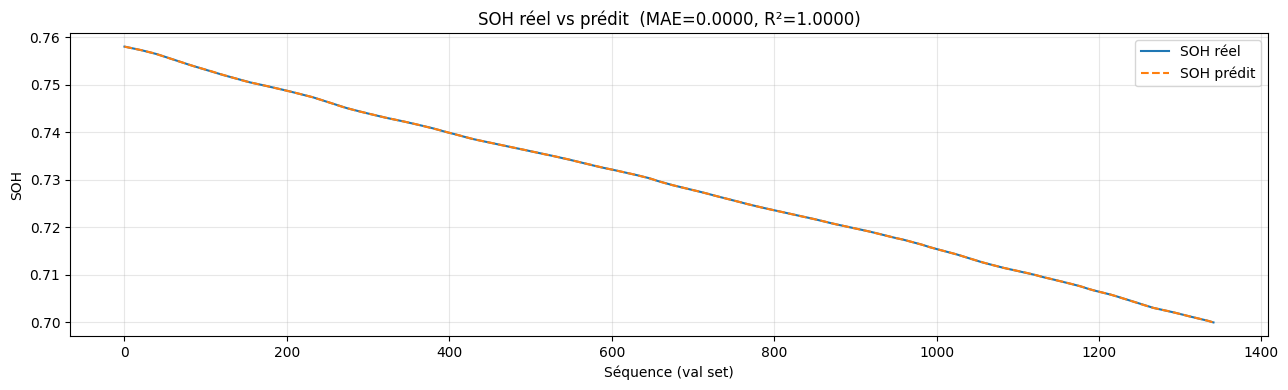

✅ soh_pred_vs_true.png sauvegardé


In [37]:
# ── SOH réel vs prédit (série temporelle) ────────────────────────────────
plt.figure(figsize=(13, 4))
plt.plot(soh_true, label='SOH réel',   lw=1.5)
plt.plot(soh_pred, label='SOH prédit', lw=1.5, ls='--')
plt.xlabel('Séquence (val set)')
plt.ylabel('SOH')
plt.title(f'SOH réel vs prédit  (MAE={mae:.4f}, R²={r2:.4f})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'soh_pred_vs_true.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ soh_pred_vs_true.png sauvegardé')

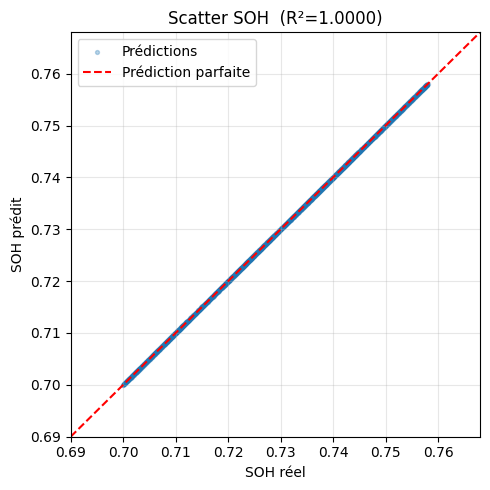

✅ scatter_soh.png sauvegardé


In [38]:
# ── Scatter ───────────────────────────────────────────────────────────────
plt.figure(figsize=(5, 5))
plt.scatter(soh_true, soh_pred, alpha=0.3, s=8, label='Prédictions')
lims = [min(soh_true.min(), soh_pred.min()) - 0.01,
        max(soh_true.max(), soh_pred.max()) + 0.01]
plt.plot(lims, lims, 'r--', lw=1.5, label='Prédiction parfaite')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('SOH réel'); plt.ylabel('SOH prédit')
plt.title(f'Scatter SOH  (R²={r2:.4f})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'scatter_soh.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ scatter_soh.png sauvegardé')

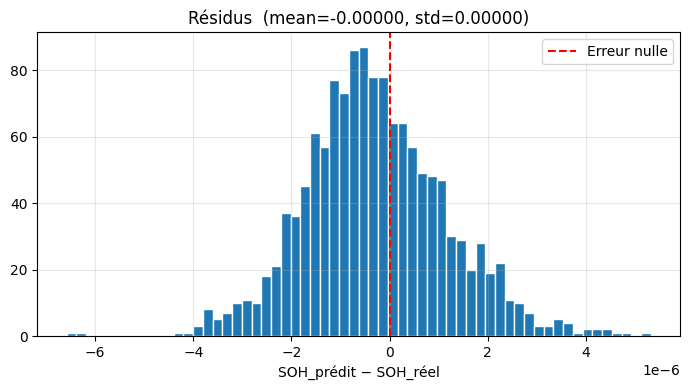

✅ residuals.png sauvegardé


In [39]:
# ── Distribution des résidus ─────────────────────────────────────────────
residuals = soh_pred - soh_true
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=60, edgecolor='white', lw=0.3)
plt.axvline(0, color='red', lw=1.5, ls='--', label='Erreur nulle')
plt.xlabel('SOH_prédit − SOH_réel')
plt.title(f'Résidus  (mean={residuals.mean():.5f}, std={residuals.std():.5f})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'residuals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ residuals.png sauvegardé')

## 14 — Sauvegarde des artefacts

In [41]:
# Modèle Keras
model_path = os.path.join(OUTPUT_DIR, 'cubesat_soh_lstm.h5')
model.save(model_path)
print(f'✅ Modèle sauvegardé      → {model_path}')

# Scalers
joblib.dump(scaler_X, os.path.join(OUTPUT_DIR, 'scaler_X.pkl'))
joblib.dump(scaler_y, os.path.join(OUTPUT_DIR, 'scaler_y.pkl'))
print(f'✅ scaler_X.pkl sauvegardé → {OUTPUT_DIR}/')
print(f'✅ scaler_y.pkl sauvegardé → {OUTPUT_DIR}/')

# Métriques
metrics_df = pd.DataFrame([{
    'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'SMAPE': smape,
    'MedianAE': medae, 'MaxError': me, 'R2': r2, 'ExplainedVariance': evs,
    'window_size': WINDOW_SIZE, 'train_cycles': len(train_df),
    'val_cycles': len(val_df),
}])
metrics_path = os.path.join(OUTPUT_DIR, 'metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'✅ Métriques sauvegardées  → {metrics_path}')

print(f'\nContenu de {OUTPUT_DIR}/')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')

✅ Modèle sauvegardé      → /content/drive/MyDrive/Colab Notebooks/outputs_2/cubesat_soh_lstm.h5
✅ scaler_X.pkl sauvegardé → /content/drive/MyDrive/Colab Notebooks/outputs_2/
✅ scaler_y.pkl sauvegardé → /content/drive/MyDrive/Colab Notebooks/outputs_2/
✅ Métriques sauvegardées  → /content/drive/MyDrive/Colab Notebooks/outputs_2/metrics.csv

Contenu de /content/drive/MyDrive/Colab Notebooks/outputs_2/
  cubesat_soh_lstm.h5
  loss_curves_fixed.png
  metrics.csv
  residuals.png
  scaler_X.pkl
  scaler_y.pkl
  scatter_soh.png
  soh_pred_vs_true.png
